# Avfallsklassificering med Transfer Learning

Det här är vårt grupprojekt i kursen *Tillämpad AI, datautvinning, maskininlärning och deep learning*.

**Vad vi gör:** vi bygger ett AI-program som tittar på en bild av skräp och gissar vilken typ det är — **återvinningsbart**, **elektronik** eller **organiskt**.

**Hur vi gör det:** vi använder en teknik som heter *transfer learning*. Det betyder att vi lånar en modell som redan är bra på att känna igen saker i bilder (den har tränats på miljontals bilder av annat, som hundar, bilar och stolar), och lär om den till att känna igen skräp istället. Det brukar gå snabbare och kräva mindre data än att träna en modell helt från noll.

**Gruppmedlemmar:** David Fjellström, Anton Hergefelt

## 1. Introduktion & problemformulering

**Problemet:** om skräp sorteras fel kostar det pengar för återvinningsföretag. I värsta fall hamnar elektronik (som kan innehålla farliga ämnen) i fel soptunna, vilket skadar miljön.

**Vår idé:** ett AI-program som känner igen avfallstyp på en bild kan hjälpa till att sortera rätt — antingen genom att göra jobbet själv, eller genom att dubbelkolla det en människa redan gjort.

Vi vill svara på tre frågor med det här projektet, i den här ordningen (fråga 1 är viktigast):

1. **Fråga 1 — Hur mycket data behövs?** Hur få bilder klarar transfer learning sig med för att bli bra? Vi jämför med en modell som tränas helt från noll, för att se skillnaden.
2. **Fråga 2 — Hur mycket av modellen behöver vi ändra?** Den lånade modellen består av många lager (steg) som bearbetar bilden. Måste vi träna om alla lager, eller räcker det med bara några av de sista?
3. **Fråga 3 — Vad kostar ett misstag?** Spelar det roll *vilket* fel modellen gör? Att tro att elektronik är organiskt avfall är värre än att blanda ihop två sorters återvinning. Vi diskuterar hur det borde påverka hur modellen används.

## 2. Data preparation (att göra bilderna redo att användas)

Vi använder ett dataset (en samling bilder med facit) från Kaggle: `fadlicr7/waste-classification-dataset`. Det har 26 527 bilder som redan är märkta med rätt kategori, och är gratis att använda (CC0-licens).

Datasetet har också en mapp som heter `test/`, men den saknar facit — den hör till en tävling som skaparen av datasetet gjort, och vi kan inte använda den för att kolla om vår modell gissar rätt. Vi delar därför upp våra egna 26 527 märkta bilder själva: en del att träna på, en del att kolla resultatet under tiden (validering), och en del att testa den färdiga modellen på (test).

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt  # för att rita diagram och visa bilder
from PIL import Image  # för att öppna bildfiler

%matplotlib inline

# Path.cwd() ger mappen vi kör notebooken från. Kör vi från notebooks/-mappen
# (vanligast) behöver vi gå upp en nivå för att hitta projektets rotmapp.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "train"  # mappen med de nedladdade bilderna
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"  # här sparar vi vår egen train/val/test-uppdelning
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"  # här sparar vi diagram till presentationen

CLASSES = ["0_Recyclable", "1_Electronic", "2_Organic"]  # de tre kategorierna vi ska känna igen
VAL_FRAC = 0.15  # andel bilder som sparas för att kolla resultat under träning
TEST_FRAC = 0.15  # andel bilder som sparas för att testa den färdiga modellen
SEED = 42  # samma "slumptal" varje gång, så uppdelningen blir likadan om vi kör om koden

### Ladda ner datasetet (körs automatiskt här — inget behövs i terminalen)

Cellen nedan gör tre saker automatiskt:

1. Kollar om `data/raw` redan har bilder — om ja, gör den ingenting (säkert att köra om)
2. Om inte: ber om din `kaggle.json` (Kaggle → Settings → API → **Create New Token**, det laddar ner filen) och laddar ner datasetet
3. Letar reda på kategorimapparna oavsett exakt namn/struktur Kaggle packade upp dem i, och skapar länkar så att `data/raw/train/0_Recyclable` m.fl. alltid pekar rätt — det här är steget som gjorde att `plot_class_examples()` kraschade tidigare, eftersom `data/raw` var tomt.

Kör cellen och följ instruktionerna som skrivs ut.

In [2]:
import subprocess

KAGGLE_JSON = Path.home() / ".kaggle" / "kaggle.json"
CLASS_KEYWORDS = {
    "0_Recyclable": "recycl",
    "1_Electronic": "electron",
    "2_Organic": "organic",
}


def setup_kaggle_credentials() -> bool:
    if KAGGLE_JSON.exists():
        return True
    try:
        from google.colab import files  # bara tillgängligt i Colab
    except ImportError:
        print("Kör inte i Colab, och ~/.kaggle/kaggle.json saknas.")
        print("Skapa filen manuellt (se README, avsnittet 'Ladda ner data') och kör om cellen.")
        return False

    print("Ladda upp din kaggle.json (Kaggle -> Settings -> API -> Create New Token):")
    uploaded = files.upload()
    if "kaggle.json" not in uploaded:
        print("Ingen fil som heter kaggle.json laddades upp. Kör om cellen och försök igen.")
        return False
    KAGGLE_JSON.parent.mkdir(parents=True, exist_ok=True)
    KAGGLE_JSON.write_bytes(uploaded["kaggle.json"])
    KAGGLE_JSON.chmod(0o600)
    print("Kaggle-credentials sparade.")
    return True


def dataset_already_downloaded(raw_dir: Path) -> bool:
    return raw_dir.exists() and any(raw_dir.rglob("*.jpg")) or (raw_dir.exists() and any(raw_dir.rglob("*.png")))


def download_dataset(raw_dir: Path = PROJECT_ROOT / "data" / "raw") -> bool:
    if dataset_already_downloaded(raw_dir):
        print(f"Bilder hittades redan i {raw_dir}, hoppar över nedladdning.")
        return True

    if not setup_kaggle_credentials():
        return False

    print("Laddar ner datasetet från Kaggle (kan ta någon minut)...")
    raw_dir.mkdir(parents=True, exist_ok=True)
    result = subprocess.run(
        ["kaggle", "datasets", "download", "-d", "fadlicr7/waste-classification-dataset",
         "-p", str(raw_dir), "--unzip"],
        capture_output=True, text=True,
    )
    print(result.stdout[-2000:])
    if result.returncode != 0:
        print("Nedladdningen misslyckades:")
        print(result.stderr[-2000:])
        return False
    print("Nedladdning klar.")
    return True


def discover_class_dirs(search_root: Path) -> dict[str, Path]:
    """Söker igenom hela search_root efter kategorimapparna, oavsett exakt
    mappnivå/namn Kaggle råkade packa upp dem i (t.ex. en extra mellanmapp,
    eller andra bokstäver än vi först antog)."""
    found: dict[str, Path] = {}
    if not search_root.exists():
        return found
    for path in sorted(search_root.rglob("*")):
        if not path.is_dir():
            continue
        name_lower = path.name.lower()
        for class_name, keyword in CLASS_KEYWORDS.items():
            if class_name in found:
                continue
            if keyword in name_lower and any(
                p.suffix.lower() in (".jpg", ".jpeg", ".png") for p in path.iterdir() if p.is_file()
            ):
                found[class_name] = path
    return found


def normalize_raw_structure(search_root: Path = PROJECT_ROOT / "data" / "raw", target_dir: Path = RAW_TRAIN_DIR) -> bool:
    """Skapar symlänkar så att data/raw/train/{CLASSES} alltid pekar rätt,
    oavsett hur datasetet faktiskt är strukturerat på disk."""
    discovered = discover_class_dirs(search_root)
    missing = [c for c in CLASSES if c not in discovered]
    if missing:
        print(f"Hittade inte alla kategorimappar. Saknas: {missing}")
        print("Mappar som faktiskt finns under data/raw just nu:")
        if search_root.exists():
            for p in sorted(search_root.rglob("*")):
                if p.is_dir():
                    print(" ", p.relative_to(PROJECT_ROOT))
        else:
            print(f"  {search_root} finns inte alls.")
        return False

    target_dir.mkdir(parents=True, exist_ok=True)
    for c, source_dir in discovered.items():
        link = target_dir / c
        if link.is_symlink() or link.exists():
            continue
        link.symlink_to(source_dir.resolve())
        print(f"  {c} -> {source_dir.relative_to(PROJECT_ROOT)} ({len(list(source_dir.glob('*')))} filer)")
    return True


if download_dataset():
    if normalize_raw_structure():
        print("\nKlart! data/raw/train innehåller nu alla tre kategorierna, redo för nästa cell.")
    else:
        print("\nNedladdning gick bra men kategorimapparna kunde inte hittas automatiskt — visa mig utskriften ovan.")
else:
    print("\nNedladdningen gick inte att slutföra — se felmeddelandet ovan.")


Bilder hittades redan i /Users/davidfjellstrom/ws/transfer-learning/data/raw, hoppar över nedladdning.



Klart! data/raw/train innehåller nu alla tre kategorierna, redo för nästa cell.


### Hur många bilder har vi per kategori?

In [3]:
def class_distribution(raw_dir: Path = RAW_TRAIN_DIR) -> dict[str, int]:
    # Räknar hur många bildfiler som finns i varje kategori-mapp
    return {c: len(list((raw_dir / c).glob("*"))) for c in CLASSES}

dist = class_distribution()
dist  # visar antal bilder per kategori

{'0_Recyclable': 9999, '1_Electronic': 3961, '2_Organic': 12567}

Vi har inte lika många bilder i varje kategori — det kallas **obalanserad data**. `1_Electronic` har mycket färre bilder än de andra två. Det tar vi hänsyn till senare, bland annat genom att alltid ta lika många bilder från varje kategori när vi bygger mindre delmängder.

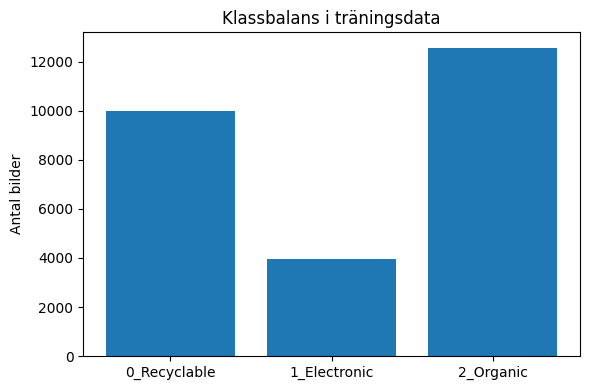

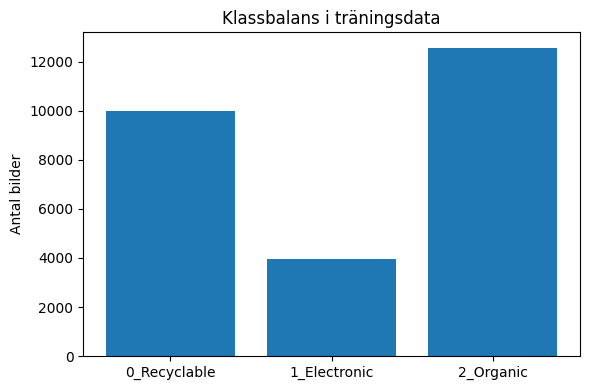

In [4]:
def plot_class_distribution(dist: dict[str, int], out_path: Path = FIGURES_DIR / "class_distribution.png"):
    # Ritar ett stapeldiagram: en stapel per kategori, höjden visar antal bilder
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(dist.keys(), dist.values())
    ax.set_ylabel("Antal bilder")
    ax.set_title("Klassbalans i träningsdata")
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path)  # sparar bilden så vi kan använda den i presentationen
    return fig

plot_class_distribution(dist)

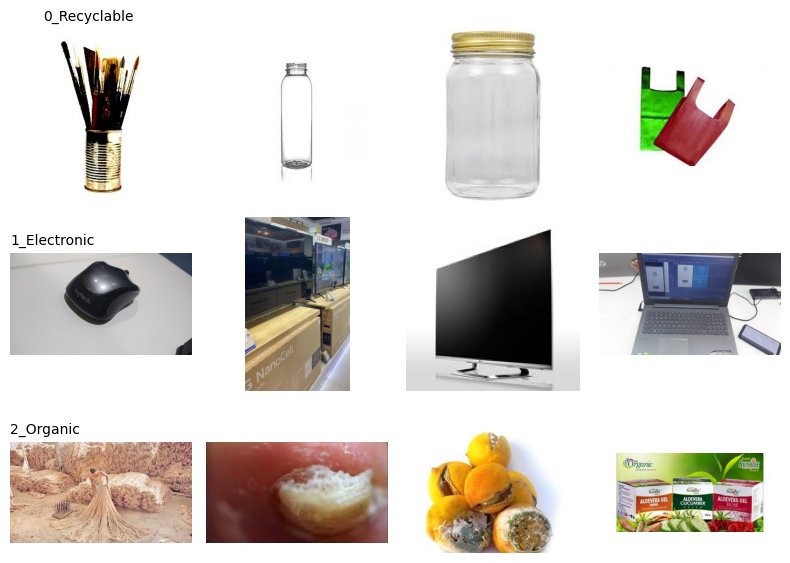

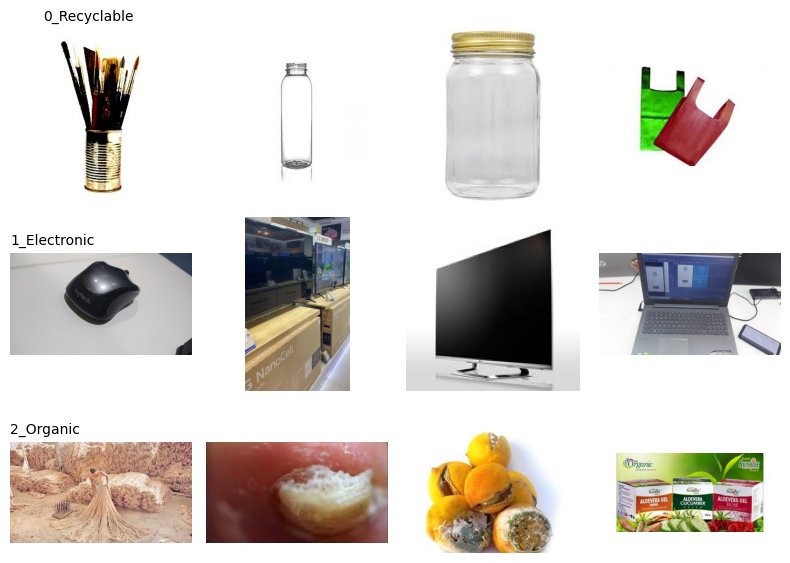

In [5]:
def plot_class_examples(
    raw_dir: Path = RAW_TRAIN_DIR,
    n_per_class: int = 4,
    seed: int = SEED,
    out_path: Path = FIGURES_DIR / "class_examples.png",
):
    # Visar n_per_class slumpmässiga exempelbilder per kategori, så vi kan se
    # med egna ögon vad "Recyclable", "Electronic" och "Organic" betyder här
    rng = random.Random(seed)
    fig, axes = plt.subplots(len(CLASSES), n_per_class, figsize=(n_per_class * 2, len(CLASSES) * 2))
    for row, c in enumerate(CLASSES):
        files = rng.sample(sorted((raw_dir / c).glob("*")), n_per_class)
        for col, f in enumerate(files):
            ax = axes[row][col]
            ax.imshow(Image.open(f))
            ax.axis("off")
            if col == 0:
                ax.set_title(c, fontsize=10, loc="left")
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path)
    return fig

plot_class_examples()

### Dela upp bilderna: träning, validering, test

Vi delar upp bilderna i tre högar, en kategori i taget (så att alla tre kategorier finns med i alla tre delarna):

- **Train (70%)** — bilderna modellen faktiskt lär sig av
- **Val (15%)** — bilder vi kollar resultatet på under träningen, för att se om modellen blir bättre eller om den bara "pluggar utantill" (overfitting)
- **Test (15%)** — bilder vi sparar helt orörda till sist, för ett ärligt slutbetyg på modellen

Vi använder samma slumptal (seed) varje gång, så uppdelningen blir exakt likadan om vi kör koden igen. Istället för att kopiera bilderna använder vi symlänkar (genvägar till samma fil), för att spara plats på disken.

In [6]:
def create_split(
    raw_dir: Path = RAW_TRAIN_DIR,
    splits_dir: Path = SPLITS_DIR,
    val_frac: float = VAL_FRAC,
    test_frac: float = TEST_FRAC,
    seed: int = SEED,
) -> None:
    rng = random.Random(seed)

    # Skapa tomma mappar för varje kombination av train/val/test och kategori
    for split in ("train", "val", "test"):
        for c in CLASSES:
            (splits_dir / split / c).mkdir(parents=True, exist_ok=True)

    for c in CLASSES:
        files = sorted((raw_dir / c).glob("*"))
        rng.shuffle(files)  # blanda bilderna slumpmässigt (men reproducerbart tack vare seed)
        n_val = int(len(files) * val_frac)
        n_test = int(len(files) * test_frac)

        # Dela upp den blandade listan: först val, sen test, resten till train
        groups = {
            "val": files[:n_val],
            "test": files[n_val : n_val + n_test],
            "train": files[n_val + n_test :],
        }
        for split, split_files in groups.items():
            for f in split_files:
                link = splits_dir / split / c / f.name
                if not link.exists():
                    link.symlink_to(f.resolve())  # skapar en genväg istället för att kopiera filen

create_split()
print(f"Split skapad i {SPLITS_DIR}")
# Räknar hur många bilder som hamnade var, som koll att det blev rätt
{f"{split}/{c}": len(list((SPLITS_DIR / split / c).glob("*"))) for split in ("train", "val", "test") for c in CLASSES}

Split skapad i /Users/davidfjellstrom/ws/transfer-learning/data/splits


{'train/0_Recyclable': 7001,
 'train/1_Electronic': 2773,
 'train/2_Organic': 8797,
 'val/0_Recyclable': 1499,
 'val/1_Electronic': 594,
 'val/2_Organic': 1885,
 'test/0_Recyclable': 1499,
 'test/1_Electronic': 594,
 'test/2_Organic': 1885}

### Dra ut mindre, jämna delar av datan

För fråga 1 (hur mycket data behövs?) behöver vi kunna plocka ut t.ex. bara 50 bilder per kategori, sen 100, sen 500 och så vidare. Här är funktionerna som gör det åt oss — de drar alltid lika många bilder från varje kategori.

In [7]:
def balanced_subset(
    n_per_class: int, split_dir: Path = SPLITS_DIR / "train", seed: int = SEED
) -> dict[str, list[Path]]:
    # Plockar ut n_per_class slumpmässiga bilder från varje kategori (samma antal från alla tre)
    rng = random.Random(seed)
    subset = {}
    for c in CLASSES:
        files = sorted((split_dir / c).glob("*"))
        if n_per_class > len(files):
            raise ValueError(f"{c} har bara {len(files)} bilder i {split_dir}, kan inte dra {n_per_class}")
        subset[c] = rng.sample(files, n_per_class)
    return subset


def materialize_subset(
    n_per_class: int, out_dir: Path, split_dir: Path = SPLITS_DIR / "train", seed: int = SEED
) -> Path:
    # Skapar en riktig mapp på disken med den mindre delmängden (som genvägar) —
    # Keras vill läsa bilder från en mapp, inte en Python-lista
    subset = balanced_subset(n_per_class, split_dir, seed)
    for c, files in subset.items():
        (out_dir / c).mkdir(parents=True, exist_ok=True)
        for f in files:
            link = out_dir / c / f.name
            if not link.exists():
                link.symlink_to(f.resolve())
    return out_dir

# Snabbtest: dra 50 bilder per kategori och kolla att det blev rätt antal
{c: len(files) for c, files in balanced_subset(50).items()}

{'0_Recyclable': 50, '1_Electronic': 50, '2_Organic': 50}

## 3. Basmodell & egna lager

Här bygger vi själva AI-modellerna.

**Käll-uppgiften** är det modellen kunde göra innan: känna igen 1000 olika saker på bilder (hundar, bilar, stolar osv), efter att ha tränats på miljontals bilder (det kallas ImageNet).

**Mål-uppgiften** är det vi vill att den ska kunna göra istället: känna igen 3 typer av skräp, med bara våra ~26 000 bilder.

**Varför funkar transfer learning?** Modellen (ResNet50V2) består av många lager efter varandra. De första lagren har lärt sig se enkla saker som kanter, hörn och färger — sånt som är användbart oavsett vad man ska känna igen på en bild. De sista lagren har lärt sig mer specifika saker, kopplat till just de 1000 ImageNet-kategorierna. Därför brukar man frysa (låta vara orörda) de första lagren, och bara träna om de sista så de passar vår uppgift istället.

Vi bygger också en enkel modell helt utan förträning ("scratch"-modellen), som jämförelse — för att kunna visa att transfer learning faktiskt gör skillnad.

In [8]:
from tensorflow.keras import Model
from tensorflow.keras.applications import ResNet50V2  # den färdigtränade modellen vi bygger vidare på
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    Input,
    MaxPooling2D,
)
from tensorflow.keras.optimizers import Adam

INPUT_SHAPE = (224, 224, 3)  # alla bilder skalas till 224x224 pixlar, 3 färgkanaler (RGB)
NUM_CLASSES = 3  # Recyclable, Electronic, Organic


def build_classification_head(base_output, dense_units: int = 128, dropout: float = 0.3):
    """Bygger de sista lagren som gör den faktiska gissningen (0/1/2).

    Samma funktion används för både TL-modellen och scratch-CNN:n, så de har
    exakt samma "sista del" och blir rättvisa att jämföra.
    """
    x = GlobalAveragePooling2D()(base_output)  # gör om bildens "features" till en enkel lista av tal
    x = Dense(dense_units, activation="relu")(x)  # ett vanligt neuralt nätverkslager
    x = BatchNormalization()(x)  # gör träningen stabilare
    x = Dropout(dropout)(x)  # stänger av en del av nätverket slumpmässigt under träning, minskar overfitting
    return Dense(NUM_CLASSES, activation="softmax")(x)  # sista lagret: en sannolikhet per kategori

**Så här tränar vi TL-modellen (i två steg):**

1. **Steg 1:** frys HELA den lånade modellen (rör den inte alls), och träna bara våra egna sista lager. Det gör att våra nya, oövade lager inte förstör den redan bra tränade modellen med stora, slumpmässiga ändringar.
2. **Steg 2:** tina upp (gör tränbara) de sista lagren i den lånade modellen också, och fortsätt träna hela grejen tillsammans — fast med en mycket lägre inlärningshastighet (learning rate). Det brukar ge stabilare resultat.

Det här skiljer sig från lärarens exempel, som gör allt i ett enda steg. Vi valde tvåstegs eftersom det brukar ge bättre och stabilare resultat. Vi har kvar en ett-stegsvariant (`build_transfer_model_single_stage`) också, som vi behöver till fråga 2 (hur mycket av modellen som behöver tinas upp).

In [9]:
def build_transfer_model(learning_rate: float = 1e-3) -> tuple[Model, Model]:
    """Steg 1: bygger TL-modellen med HELA den lånade basen fryst.

    Returnerar både hela modellen och bas-modellen för sig, eftersom vi
    behöver bas-modellen senare för att tina upp lager i steg 2.
    """
    base_model = ResNet50V2(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE)
    base_model.trainable = False  # frys hela den lånade modellen

    output = build_classification_head(base_model.output)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",  # standardval för klassificering med fler än 2 kategorier
        metrics=["accuracy"],
    )
    return model, base_model


def unfreeze_top_layers(model: Model, base_model: Model, n_layers: int, learning_rate: float = 1e-5) -> Model:
    """Steg 2: tinar upp de sista n_layers lagren i basen, och kompilerar om med lägre learning rate."""
    base_model.trainable = True
    if n_layers < len(base_model.layers):
        # frys alla lager UTOM de sista n_layers
        for layer in base_model.layers[:-n_layers]:
            layer.trainable = False

    model.compile(
        # mycket lägre learning rate än steg 1, så vi inte förstör det modellen redan kan
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_transfer_model_single_stage(unfrozen_layers: int = 30, learning_rate: float = 5e-5) -> Model:
    """Ett-stegs variant (som lärarens exempel): basen fryst förutom de sista unfrozen_layers lagren.

    Byggs och tränas direkt, utan mellansteg. Används i fråga 2, där vi
    testar olika antal upptinade lager (0, 10, 30, alla).
    """
    base_model = ResNet50V2(weights="imagenet", include_top=False, input_shape=INPUT_SHAPE)
    base_model.trainable = unfrozen_layers > 0
    if 0 < unfrozen_layers < len(base_model.layers):
        for layer in base_model.layers[:-unfrozen_layers]:
            layer.trainable = False

    output = build_classification_head(base_model.output)
    model = Model(inputs=base_model.input, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_scratch_cnn(learning_rate: float = 1e-3) -> Model:
    """Bygger en enkel CNN helt UTAN förträning — jämförelsemodellen för fråga 1.

    Fyra vanliga Conv2D + MaxPooling-block, ingen ImageNet-kunskap alls.
    Delar samma sista lager (build_classification_head) som TL-modellen,
    så jämförelsen blir rättvis.
    """
    inputs = Input(shape=INPUT_SHAPE)
    x = inputs
    for filters in (32, 64, 128, 128):
        x = Conv2D(filters, 3, activation="relu", padding="same")(x)  # letar efter mönster i bilden
        x = MaxPooling2D()(x)  # gör bilden mindre/enklare steg för steg

    output = build_classification_head(x)
    model = Model(inputs=inputs, outputs=output)
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

In [10]:
# Bygger alla fyra modellvarianter och skriver ut hur många parametrar (inställbara
# tal) varje modell har totalt, och hur många av dem som faktiskt är tränbara just nu.
tl_model, base_model = build_transfer_model()
print(f"TL-modell (steg 1, bas fryst): {tl_model.count_params():,} params totalt, "
      f"{sum(w.shape.num_elements() for w in tl_model.trainable_weights):,} tränbara")

unfreeze_top_layers(tl_model, base_model, n_layers=30)
print(f"TL-modell (steg 2, sista 30 lagren upptinade): "
      f"{sum(w.shape.num_elements() for w in tl_model.trainable_weights):,} tränbara")

single_stage = build_transfer_model_single_stage(unfrozen_layers=30)
print(f"TL-modell (ett-stegs, lärarens mönster): {single_stage.count_params():,} params totalt")

scratch_model = build_scratch_cnn()
print(f"Scratch-CNN: {scratch_model.count_params():,} params totalt, "
      f"{sum(w.shape.num_elements() for w in scratch_model.trainable_weights):,} tränbara")

TL-modell (steg 1, bas fryst): 23,827,971 params totalt, 262,915 tränbara
TL-modell (steg 2, sista 30 lagren upptinade): 14,706,435 tränbara


TL-modell (ett-stegs, lärarens mönster): 23,827,971 params totalt
Scratch-CNN: 258,243 params totalt, 257,987 tränbara


## 4. Experiment 1: hur mycket data behövs? (fråga 1, huvudfrågan)

Vi har många bilder (26 527 st), så "vi fick 99% rätt" säger inte så mycket i sig själv — det säger inget om *hur* vi kom dit. Den intressanta frågan är: hur lite data klarar vi oss med?

Vi tränar TL-modellen och scratch-CNN:n på växande mängder bilder (t.ex. 50, 100, 500, 2000, och till slut alla bilder per kategori), och ritar en kurva: x-axeln är antal bilder, y-axeln är hur bra modellen gissar (val-accuracy). Två linjer i samma diagram: en för TL, en för scratch. Den kurvan blir huvudbilden i presentationen.

**[TODO: vi kör det här experimentet tillsammans senare — det kräver GPU och tar tid. Cellen nedan är förberedd men inte körd än.]**

--- n=50 bilder/kategori ---
  TL:      val_acc=0.875 val_loss=0.396
  Scratch: val_acc=0.483 val_loss=0.976
--- n=100 bilder/kategori ---
  TL:      val_acc=0.865 val_loss=0.425
  Scratch: val_acc=0.467 val_loss=0.966
--- n=500 bilder/kategori ---
  TL:      val_acc=0.902 val_loss=0.344
  Scratch: val_acc=0.783 val_loss=0.532
--- n=2000 bilder/kategori ---
  TL:      val_acc=0.923 val_loss=0.282
  Scratch: val_acc=0.780 val_loss=0.561
--- n=2773 bilder/kategori ---
  TL:      val_acc=0.925 val_loss=0.281
  Scratch: val_acc=0.837 val_loss=0.421


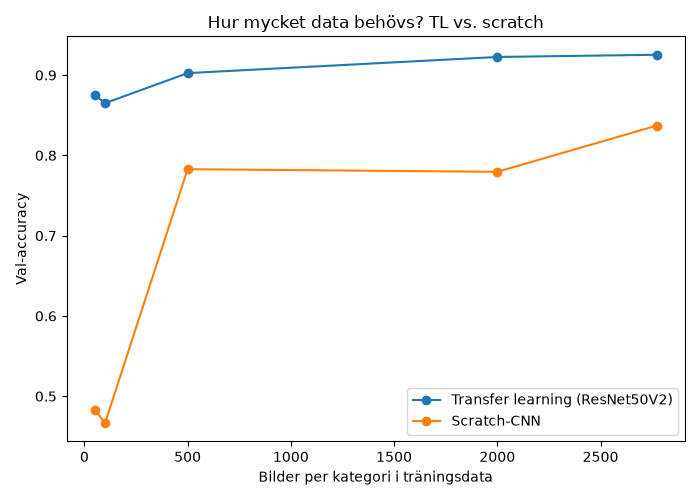

In [1]:
# Experiment 1: hur mycket data behövs? (fråga 1, huvudfrågan)
# Tränar TL-modellen (två steg) och scratch-CNN:n på växande datamängder,
# sparar val-accuracy/val-loss för varje storlek, och ritar kurvan.
# Inte körd ännu — vi kör det här tillsammans, det tar tid även med GPU.

import json

import tensorflow as tf
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess

SUBSET_SIZES = [50, 100, 500, 2000]  # + "alla" läggs på automatiskt av run_experiment1
EPOCHS_STAGE1 = 10  # steg 1: bara vårt huvud tränas (bas fryst)
EPOCHS_STAGE2 = 5  # steg 2: sista lagren i basen upptinade, låg learning rate
EPOCHS_SCRATCH = 15  # scratch-CNN:n har ingen förträning, behöver fler epoker
UNFREEZE_LAYERS_EXP1 = 30  # rimligt standardval här; experiment 2 svarar på vad som faktiskt är bäst
EXPERIMENT1_RESULTS_PATH = PROJECT_ROOT / "reports" / "experiment1_results.json"


import numpy as np
from PIL import ImageOps

def _load_and_pad_pil(path_tensor, target_size):
    # Läser en bildfil och skalar den till target_size UTAN att förvränga
    # bildförhållandet (fyller ut med svart istället), som README beskriver.
    # Vi provade tf.image.resize_with_pad här, men den kraschar oförutsägbart
    # inne i en tf.data-pipeline ("Input shape axis 0 must equal 4, got shape
    # [5]") — en känd TensorFlow-bugg. PIL:s ImageOps.pad gör exakt samma sak
    # (resize + svart utfyllnad) helt tillförlitligt.
    path = path_tensor.numpy().decode("utf-8")
    img = Image.open(path).convert("RGB")
    img = ImageOps.pad(img, target_size, color=(0, 0, 0))
    return np.asarray(img, dtype=np.float32)


def _load_and_pad(path, label, target_size=INPUT_SHAPE[:2]):
    # py_function kör PIL-koden "vanligt" (eagerly) per bild, eftersom PIL
    # inte förstår TensorFlows grafläge.
    img = tf.py_function(func=lambda p: _load_and_pad_pil(p, target_size), inp=[path], Tout=tf.float32)
    img.set_shape([target_size[0], target_size[1], 3])
    return img, label


def build_dataset(directory: Path, batch_size: int = 32, shuffle: bool = True, preprocess=None) -> tf.data.Dataset:
    """Bygger ett tf.data-dataset från en mapp med en undermapp per kategori (symlänkar funkar fint)."""
    paths, labels = [], []
    for idx, c in enumerate(CLASSES):
        class_files = sorted((directory / c).glob("*"))
        paths.extend(str(f) for f in class_files)
        labels.extend([idx] * len(class_files))

    labels_onehot = tf.keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels_onehot))
    if shuffle:
        ds = ds.shuffle(buffer_size=max(len(paths), 1), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load_and_pad, num_parallel_calls=tf.data.AUTOTUNE)
    if preprocess is not None:
        ds = ds.map(lambda x, l: (preprocess(x), l), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def train_tl_model(train_dir: Path, val_dir: Path, batch_size: int = 32) -> tuple[float, float]:
    train_ds = build_dataset(train_dir, batch_size=batch_size, shuffle=True, preprocess=resnet_preprocess)
    val_ds = build_dataset(val_dir, batch_size=batch_size, shuffle=False, preprocess=resnet_preprocess)

    model, base_model = build_transfer_model()
    model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE1, verbose=0)

    unfreeze_top_layers(model, base_model, n_layers=UNFREEZE_LAYERS_EXP1)
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_STAGE2, verbose=0)
    return history.history["val_accuracy"][-1], history.history["val_loss"][-1]


def train_scratch_model(train_dir: Path, val_dir: Path, batch_size: int = 32) -> tuple[float, float]:
    rescale = lambda x: x / 255.0
    train_ds = build_dataset(train_dir, batch_size=batch_size, shuffle=True, preprocess=rescale)
    val_ds = build_dataset(val_dir, batch_size=batch_size, shuffle=False, preprocess=rescale)

    model = build_scratch_cnn()
    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_SCRATCH, verbose=0)
    return history.history["val_accuracy"][-1], history.history["val_loss"][-1]


def run_experiment1(subset_sizes=SUBSET_SIZES, include_all: bool = True) -> dict:
    val_dir = SPLITS_DIR / "val"
    results = {"tl": {}, "scratch": {}}

    sizes = list(subset_sizes)
    if include_all:
        sizes.append(min(class_distribution(SPLITS_DIR / "train").values()))

    for n in sizes:
        subset_dir = PROJECT_ROOT / "data" / "tmp_subset" / f"n{n}"
        materialize_subset(n, subset_dir, split_dir=SPLITS_DIR / "train")

        print(f"--- n={n} bilder/kategori ---")
        tl_acc, tl_loss = train_tl_model(subset_dir, val_dir)
        print(f"  TL:      val_acc={tl_acc:.3f} val_loss={tl_loss:.3f}")
        results["tl"][n] = {"val_accuracy": tl_acc, "val_loss": tl_loss}

        scratch_acc, scratch_loss = train_scratch_model(subset_dir, val_dir)
        print(f"  Scratch: val_acc={scratch_acc:.3f} val_loss={scratch_loss:.3f}")
        results["scratch"][n] = {"val_accuracy": scratch_acc, "val_loss": scratch_loss}

    EXPERIMENT1_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    EXPERIMENT1_RESULTS_PATH.write_text(json.dumps(results, indent=2))
    return results


def plot_experiment1(results: dict, out_path: Path = FIGURES_DIR / "experiment1_data_needed.png"):
    sizes = sorted(results["tl"].keys(), key=int)
    tl_accs = [results["tl"][n]["val_accuracy"] for n in sizes]
    scratch_accs = [results["scratch"][n]["val_accuracy"] for n in sizes]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(sizes, tl_accs, marker="o", label="Transfer learning (ResNet50V2)")
    ax.plot(sizes, scratch_accs, marker="o", label="Scratch-CNN")
    ax.set_xlabel("Bilder per kategori i träningsdata")
    ax.set_ylabel("Val-accuracy")
    ax.set_title("Hur mycket data behövs? TL vs. scratch")
    ax.legend()
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path)
    return fig


# Kört tillsammans - resultat nedan.
results1 = run_experiment1()
plot_experiment1(results1)


## 5. Experiment 2: hur mycket av modellen behöver tinas upp? (fråga 2)

Med den bästa datamängden från experiment 1 tränar vi samma TL-modell flera gånger, men med olika antal upptinade (tränbara) lager i basen: 0 (bara vårt eget huvud), ~10, ~30, och till sist alla lager. Vi ritar en kurva: antal upptinade lager på x-axeln, val-accuracy på y-axeln.

Det här förklarar *varför* transfer learning funkar, inte bara *att* det funkar — kopplat till det vi sa tidigare om att tidiga lager har lärt sig generella saker (kanter, former) medan sena lager är mer specialiserade.

**[TODO: kör tillsammans senare — kräver GPU och tar tid.]**

--- upptinade lager: 0 ---
  val_acc=0.927 val_loss=0.211
--- upptinade lager: 10 ---
  val_acc=0.928 val_loss=0.255
--- upptinade lager: 30 ---
  val_acc=0.934 val_loss=0.281
--- upptinade lager: alla ---
  val_acc=0.933 val_loss=0.281


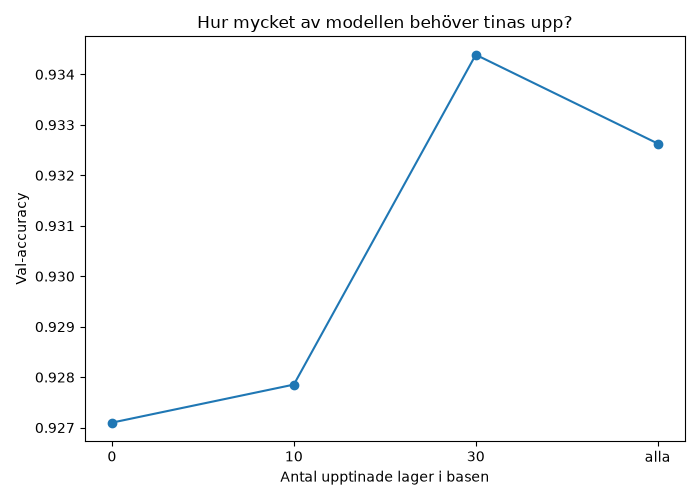

In [1]:
# Experiment 2: hur mycket av modellen behöver tinas upp? (fråga 2)
# Tränar TL-modellen flera gånger med olika antal upptinade lager i basen,
# med den bästa datamängden från experiment 1.

UNFROZEN_LAYER_COUNTS = [0, 10, 30, None]  # None betyder hela basen upptinad
BEST_SUBSET_SIZE = 2773  # bästa datamängden från experiment 1 (alla bilder/kategori gav högst val-accuracy)
EPOCHS_EXP2 = 12
EXPERIMENT2_RESULTS_PATH = PROJECT_ROOT / "reports" / "experiment2_results.json"


def run_experiment2(unfrozen_counts=UNFROZEN_LAYER_COUNTS, n_per_class: int | None = BEST_SUBSET_SIZE, batch_size: int = 32) -> dict:
    if n_per_class is None:
        raise ValueError("Sätt BEST_SUBSET_SIZE till bästa datamängden från experiment 1 innan du kör det här.")

    subset_dir = PROJECT_ROOT / "data" / "tmp_subset" / f"n{n_per_class}"
    materialize_subset(n_per_class, subset_dir, split_dir=SPLITS_DIR / "train")
    val_dir = SPLITS_DIR / "val"

    train_ds = build_dataset(subset_dir, batch_size=batch_size, shuffle=True, preprocess=resnet_preprocess)
    val_ds = build_dataset(val_dir, batch_size=batch_size, shuffle=False, preprocess=resnet_preprocess)

    total_layers = len(ResNet50V2(weights=None, include_top=False, input_shape=INPUT_SHAPE).layers)

    results = {}
    for n_layers in unfrozen_counts:
        unfrozen = total_layers if n_layers is None else n_layers
        label = "alla" if n_layers is None else str(n_layers)
        print(f"--- upptinade lager: {label} ---")

        model = build_transfer_model_single_stage(unfrozen_layers=unfrozen)
        history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_EXP2, verbose=0)
        val_acc, val_loss = history.history["val_accuracy"][-1], history.history["val_loss"][-1]
        print(f"  val_acc={val_acc:.3f} val_loss={val_loss:.3f}")
        results[label] = {"val_accuracy": val_acc, "val_loss": val_loss, "n_layers": unfrozen}

    EXPERIMENT2_RESULTS_PATH.parent.mkdir(parents=True, exist_ok=True)
    EXPERIMENT2_RESULTS_PATH.write_text(json.dumps(results, indent=2))
    return results


def plot_experiment2(results: dict, out_path: Path = FIGURES_DIR / "experiment2_unfrozen_layers.png"):
    labels = list(results.keys())
    accs = [results[l]["val_accuracy"] for l in labels]

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(labels, accs, marker="o")
    ax.set_xlabel("Antal upptinade lager i basen")
    ax.set_ylabel("Val-accuracy")
    ax.set_title("Hur mycket av modellen behöver tinas upp?")
    fig.tight_layout()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path)
    return fig


# Kört tillsammans - resultat nedan.
results2 = run_experiment2(n_per_class=BEST_SUBSET_SIZE)
plot_experiment2(results2)


## 6. Utvärdering & vad kostar ett misstag? (fråga 3)

När vi valt den bästa modellen (utifrån experiment 1 och 2) kollar vi den mer noggrant:

- **Confusion matrix** — en tabell som visar exakt vilka kategorier modellen blandar ihop
- **classification_report** — mer detaljerade siffror per kategori (precision, recall, F1)
- En diskussion: vilket misstag är värst för ett återvinningsföretag? Att tro att elektronik är organiskt avfall är värre än att blanda ihop två återvinningstyper, eftersom elektronik kan innehålla farliga ämnen. Det borde påverka hur försiktig modellen ska vara innan den litar på sin egen gissning.
- Om vi hinner: Grad-CAM — bilder som visar *var* på bilden modellen tittade när den gissade, som bevis på att den faktiskt lärt sig rätt saker.

**[TODO: körs efter att bästa modellen är vald. Vi hittar inte på resultat i förväg.]**

              precision    recall  f1-score   support

0_Recyclable       0.91      0.91      0.91      1499
1_Electronic       0.88      0.97      0.92       594
   2_Organic       0.94      0.92      0.93      1885

    accuracy                           0.92      3978
   macro avg       0.91      0.93      0.92      3978
weighted avg       0.92      0.92      0.92      3978


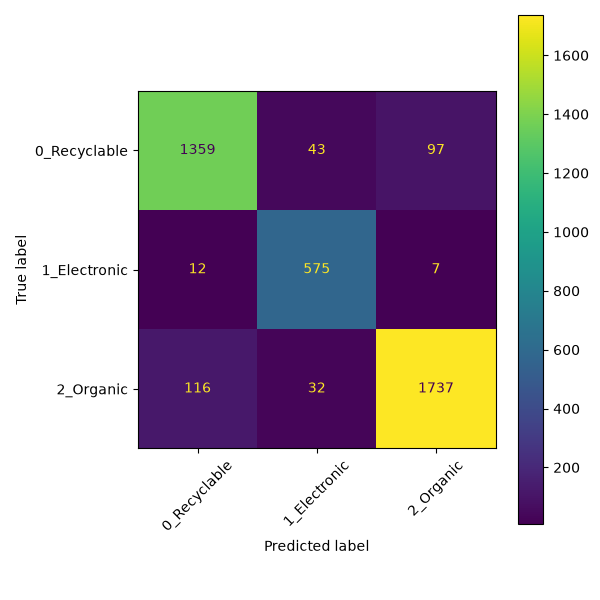

In [2]:
# Utvärdering av slutgiltiga bästa modellen (fråga 3): confusion matrix,
# classification_report.

import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

BEST_UNFROZEN_LAYERS = 30  # bästa antalet upptinade lager från experiment 2 (högst val-accuracy)


def train_best_model(n_per_class: int | None = BEST_SUBSET_SIZE, unfrozen_layers: int | None = BEST_UNFROZEN_LAYERS,
                      batch_size: int = 32, epochs: int = EPOCHS_EXP2) -> Model:
    if n_per_class is None or unfrozen_layers is None:
        raise ValueError("Sätt BEST_SUBSET_SIZE och BEST_UNFROZEN_LAYERS innan du tränar slutmodellen.")

    subset_dir = PROJECT_ROOT / "data" / "tmp_subset" / f"n{n_per_class}"
    materialize_subset(n_per_class, subset_dir, split_dir=SPLITS_DIR / "train")

    train_ds = build_dataset(subset_dir, batch_size=batch_size, shuffle=True, preprocess=resnet_preprocess)
    val_ds = build_dataset(SPLITS_DIR / "val", batch_size=batch_size, shuffle=False, preprocess=resnet_preprocess)

    model = build_transfer_model_single_stage(unfrozen_layers=unfrozen_layers)
    model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=0)
    return model


def evaluate_best_model(model: Model, batch_size: int = 32):
    test_ds = build_dataset(SPLITS_DIR / "test", batch_size=batch_size, shuffle=False, preprocess=resnet_preprocess)

    y_true, y_pred = [], []
    for images, labels in test_ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(np.argmax(labels.numpy(), axis=1))
        y_pred.extend(np.argmax(preds, axis=1))

    print(classification_report(y_true, y_pred, target_names=CLASSES))

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, xticks_rotation=45)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "confusion_matrix.png")
    return cm, fig


# Kört tillsammans - resultat nedan.
best_model = train_best_model(n_per_class=BEST_SUBSET_SIZE, unfrozen_layers=BEST_UNFROZEN_LAYERS)
cm, fig = evaluate_best_model(best_model)


## 7. Sammanfattning & affärsnytta

**[TODO: skrivs sist, efter alla experiment. Ska svara på de tre frågorna, förklara vad felsortering kostar idag, vad modellen skulle ge ett återvinningsföretag, och vilka begränsningar den har.]**